In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten

In [2]:
data_dir = "../data"
train_dir = data_dir+"/train"
test_dir = data_dir+"/test"

In [3]:
# For split the data to specified classes
try:
    for fnames in os.listdir(train_dir):
        src = os.path.join(train_dir,fnames)
        classes = fnames.split('.')[0]
        folder = os.path.join(train_dir,classes)
        if not(os.path.exists(folder)):
            os.mkdir(folder)
        des = os.path.join(folder,fnames)
        os.rename(src,des)
except:
    print("The data already splitted")

The data already splitted


In [4]:
datagen = ImageDataGenerator(rescale = 1/255,validation_split=0.2)
target = (60,60)

train_set = datagen.flow_from_directory(train_dir,
                                        shuffle=True,
                                        target_size = target,
                                        batch_size = 64,
                                        class_mode = 'binary',
                                        subset = 'training')

valid_set = datagen.flow_from_directory(train_dir,
                                        shuffle=True,
                                        target_size = target,
                                        batch_size = 32,
                                        class_mode = 'binary',
                                        subset = 'validation')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [5]:
learning_rate = 0.01

model = Sequential([
    Convolution2D(16,3,input_shape=(60,60,3),activation='relu'),
    MaxPooling2D(2),
    Convolution2D(32,3,activation='relu'),
    MaxPooling2D(2),
    Convolution2D(64,3,activation='relu'),
    MaxPooling2D(2),
    Flatten(),
    Dense(512,activation='relu'),
    Dense(1,activation='sigmoid')
])
model.summary()

model.compile(loss='mse',optimizer='adam',metrics=['acc'])
model.optimizer.get_config()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 58, 58, 16)        448       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 29, 29, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 27, 27, 32)        4640      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 11, 11, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 5, 5, 64)          0         
_________________________________________________________________
flatten (Flatten)            (None, 1600)              0

{'name': 'Adam',
 'learning_rate': 0.001,
 'decay': 0.0,
 'beta_1': 0.9,
 'beta_2': 0.999,
 'epsilon': 1e-07,
 'amsgrad': False}

In [6]:
history = model.fit(train_set,
                    validation_data=valid_set,
                    steps_per_epoch=train_set.n//train_set.batch_size,
                    validation_steps=valid_set.n//valid_set.batch_size,
                    epochs = 15)

Epoch 1/15
312/312 [==============================] - 45s 105ms/step - loss: 0.2325 - acc: 0.5884 - val_loss: 0.1756 - val_acc: 0.7354
Epoch 2/15
312/312 [==============================] - 33s 106ms/step - loss: 0.1738 - acc: 0.7406 - val_loss: 0.1608 - val_acc: 0.7656
Epoch 3/15
312/312 [==============================] - 32s 103ms/step - loss: 0.1480 - acc: 0.7837 - val_loss: 0.1478 - val_acc: 0.7796
Epoch 4/15
312/312 [==============================] - 33s 106ms/step - loss: 0.1309 - acc: 0.8140 - val_loss: 0.1550 - val_acc: 0.7726
Epoch 5/15
312/312 [==============================] - 32s 103ms/step - loss: 0.1146 - acc: 0.8419 - val_loss: 0.1367 - val_acc: 0.8031
Epoch 6/15
312/312 [==============================] - 33s 105ms/step - loss: 0.0996 - acc: 0.8675 - val_loss: 0.1277 - val_acc: 0.8159
Epoch 7/15
312/312 [==============================] - 33s 105ms/step - loss: 0.0898 - acc: 0.8805 - val_loss: 0.1303 - val_acc: 0.8179
Epoch 8/15
312/312 [==============================] - 3

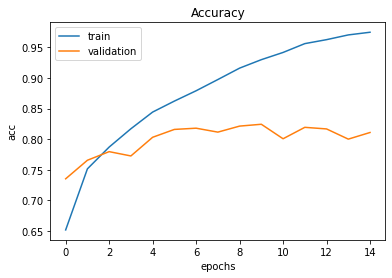

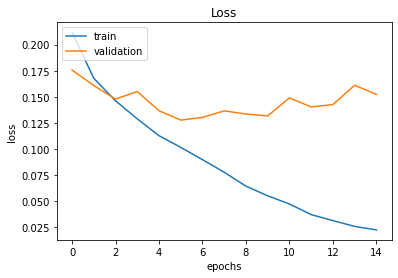

In [8]:
legend = ['train','validation']

plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title("Accuracy")
plt.xlabel("epochs")
plt.ylabel("acc")
plt.legend(legend,loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(legend,loc='upper left')
plt.show()